<a href="https://colab.research.google.com/github/NischalGrg5555/AI-Level-6/blob/main/Worksheet7_2414016.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nischal Gurung - Workshop 7

**Exercise: Build a Denoising Convolutional Autoencoder**

**Dataset Preparation and Preprocessing:**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
np.random.seed(42)

In [ ]:
train_path = "/content/drive/MyDrive/AI/Week4/DevanagariHandwrittenDigitDataset/Train"
test_path = "/content/drive/MyDrive/AI/Week4/DevanagariHandwrittenDigitDataset/Test"

In [ ]:
def load_images_from_folder(folder_path, image_size=(32, 32)):
    images = []
    for label_folder in sorted(os.listdir(folder_path)):
        label_path = os.path.join(folder_path, label_folder)
        if not os.path.isdir(label_path):
            continue
        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            try:
                img = Image.open(img_path).convert("L")  # Convert to grayscale
                img = img.resize(image_size)
                img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize to [0, 1]
                images.append(img_array)
            except Exception as e:
                print(f" Failed to read {img_path} — {e}")
    return np.array(images)

In [ ]:
train_images = load_images_from_folder(train_path)
test_images = load_images_from_folder(test_path)

In [ ]:
all_images = np.concatenate((train_images, test_images), axis=0)
print("Total images loaded:", all_images.shape)

Total images loaded: (14469, 32, 32)


In [ ]:
all_images = all_images.reshape((-1, 32, 32, 1))

In [ ]:
noise_factor = 0.5
noisy_images = all_images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=all_images.shape)
noisy_images = np.clip(noisy_images, 0., 1.)

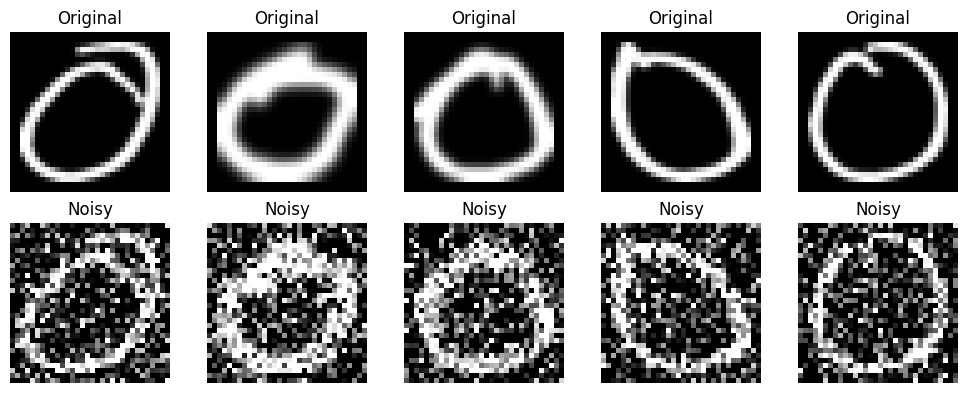

In [ ]:
import matplotlib.pyplot as plt

n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(all_images[i].reshape(32, 32), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(noisy_images[i].reshape(32, 32), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Build the Denoising Convolutional Autoencoder:**

In [ ]:
# Encoder
def build_encoder(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

    return input_img, encoded

# Decoder
def build_decoder(encoded_input):
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

# Combine into Autoencoder
def build_autoencoder():
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

In [ ]:
# Build and view summary
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

**Train the Denoising Autoencoder:**

In [ ]:
x_train, x_val, x_train_noisy, x_val_noisy = train_test_split(
    all_images, noisy_images, test_size=0.2, random_state=42
)

# Train the autoencoder
history = autoencoder.fit(
    x_train_noisy, x_train,  # Noisy input, clean target
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 46s 481ms/step - loss: 0.4644 - val_loss: 0.2058
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 470ms/step - loss: 0.1946 - val_loss: 0.1800
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 82s 473ms/step - loss: 0.1767 - val_loss: 0.1722
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 78s 429ms/step - loss: 0.1693 - val_loss: 0.1652
Epoch 5/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 41s 428ms/step - loss: 0.1650 - val_loss: 0.1670
Epoch 6/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 41s 429ms/step - loss: 0.1628 - val_loss: 0.1603
Epoch 7/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 41s 429ms/step - loss: 0.1599 - val_loss: 0.1590
Epoch 8/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 44s 461ms/step - loss: 0.1591 - val_loss: 0.1578
Epoch 9/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 43s 471ms/step - loss: 0.1572 - val_loss: 0.1564
Epoch 10/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 79s 443ms/step - loss: 0.1562 - val_loss: 0.1555
Epoch 11/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 42s 462ms/step - loss: 0.1554 - val_loss: 0.1553
Epoch 12/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 81

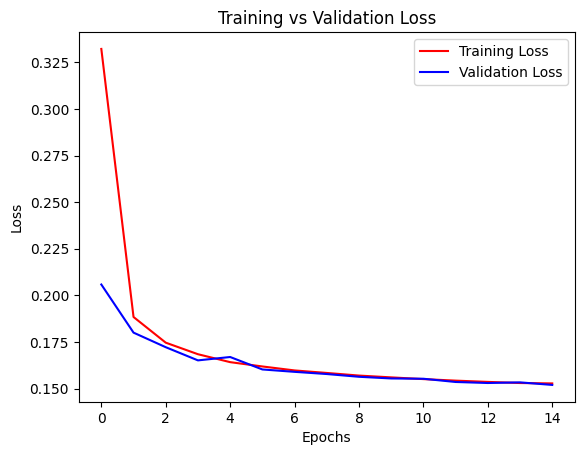

In [ ]:
#Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss', color="red")
plt.plot(history.history['val_loss'], label='Validation Loss', color="blue")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

**Evaluate and Visualize the Results:**

91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


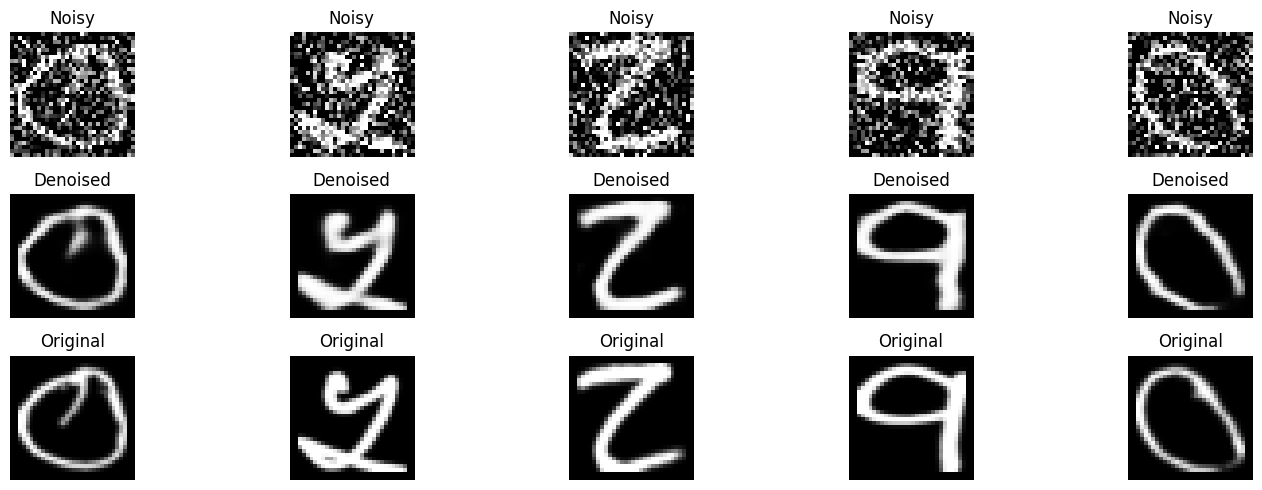

In [ ]:
# Prediction on validation set
denoised_images = autoencoder.predict(x_val_noisy)

# Function to visualize results
def plot_images(noisy, denoised, clean, n=5):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        # Noisy
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(noisy[i].reshape(32, 32), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised[i].reshape(32, 32), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        # Ground Truth
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean[i].reshape(32, 32), cmap='gray')
        plt.title("Original")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Calling the function
plot_images(x_val_noisy, denoised_images, x_val, n=5)

In [ ]:
from sklearn.metrics import mean_squared_error

mse_scores = []
for i in range(len(x_val)):
    mse = mean_squared_error(x_val[i].flatten(), denoised_images[i].flatten())
    mse_scores.append(mse)

print(f"Average MSE on validation set: {np.mean(mse_scores):.5f}")

Average MSE on validation set: 0.01361


**Experiment and Fine - Tune the Model:**

In [ ]:
def build_encoder_deep(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)
    return input_img, encoded

def build_decoder_deep(encoded_input):
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    return decoded

def build_autoencoder_deep():
    input_img, encoded = build_encoder_deep()
    decoded = build_decoder_deep(encoded)
    autoencoder = Model(inputs=input_img, outputs=decoded)
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

# Build and retrain deep autoencoder
autoencoder_deep = build_autoencoder_deep()
autoencoder_deep.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Different noise level
noise_factor_test = 0.5

x_train_noisy_test = x_train + noise_factor_test * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_val_noisy_test = x_val + noise_factor_test * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)

x_train_noisy_test = np.clip(x_train_noisy_test, 0., 1.)
x_val_noisy_test = np.clip(x_val_noisy_test, 0., 1.)

# Retrain model on the noise
history_test = autoencoder.fit(
    x_train_noisy_test, x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy_test, x_val)
)

Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 40s 442ms/step - loss: 0.1518 - val_loss: 0.1504
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 40s 431ms/step - loss: 0.1507 - val_loss: 0.1502
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 41s 437ms/step - loss: 0.1509 - val_loss: 0.1501
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 40s 434ms/step - loss: 0.1508 - val_loss: 0.1501
Epoch 5/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 44s 471ms/step - loss: 0.1500 - val_loss: 0.1492
Epoch 6/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 79s 439ms/step - loss: 0.1497 - val_loss: 0.1489
Epoch 7/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 41s 445ms/step - loss: 0.1490 - val_loss: 0.1496
Epoch 8/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 41s 449ms/step - loss: 0.1491 - val_loss: 0.1483
Epoch 9/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 41s 446ms/step - loss: 0.1485 - val_loss: 0.1481
Epoch 10/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 41s 447ms/step - loss: 0.1479 - val_loss: 0.1477
Epoch 11/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 42s 460ms/step - loss: 0.1479 - val_loss: 0.1477
Epoch 12/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 40

In [ ]:
retrained_loss = [0.1518, 0.1507, 0.1509, 0.1508, 0.1500, 0.1497, 0.1490, 0.1491, 0.1485, 0.1479, 0.1479, 0.1482, 0.1470, 0.1470, 0.1472]
retrained_val_loss = [0.1504, 0.1502, 0.1501, 0.1501, 0.1492, 0.1489, 0.1496, 0.1483, 0.1481, 0.1477, 0.1477, 0.1473, 0.1473, 0.1470, 0.1469]

In [ ]:
baseline_loss = history.history['loss']
baseline_val_loss = history.history['val_loss']

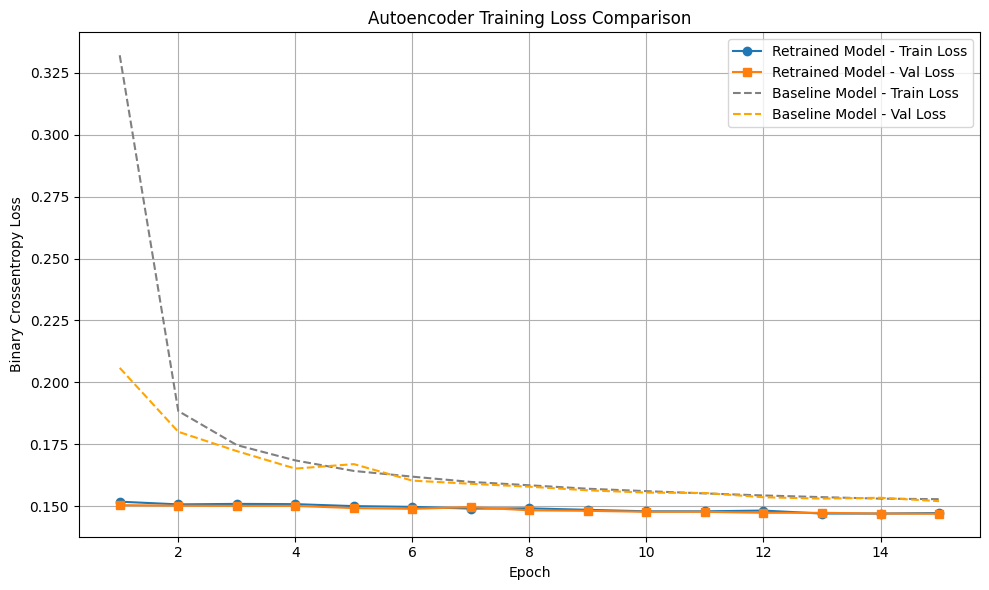

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(retrained_loss) + 1))

plt.figure(figsize=(10, 6))

# Retrained model plot
plt.plot(epochs, retrained_loss, label='Retrained Model - Train Loss', marker='o')
plt.plot(epochs, retrained_val_loss, label='Retrained Model - Val Loss', marker='s')

#Earlier model plot
try:
    plt.plot(range(1, len(baseline_loss)+1), baseline_loss, label='Baseline Model - Train Loss', linestyle='--', color='gray')
    plt.plot(range(1, len(baseline_val_loss)+1), baseline_val_loss, label='Baseline Model - Val Loss', linestyle='--', color='orange')
except:
    pass

plt.title("Autoencoder Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

I tried changing the noise levels and also made the model deeper by adding more layers. I noticed that when I added more noise, the model had a harder time learning and the loss didn’t go down as much. But when I made the model deeper, it performed better overall — the loss kept decreasing steadily and the results looked cleaner. So, tweaking the architecture and training settings made a noticeable difference in how well the autoencoder worked.